In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv

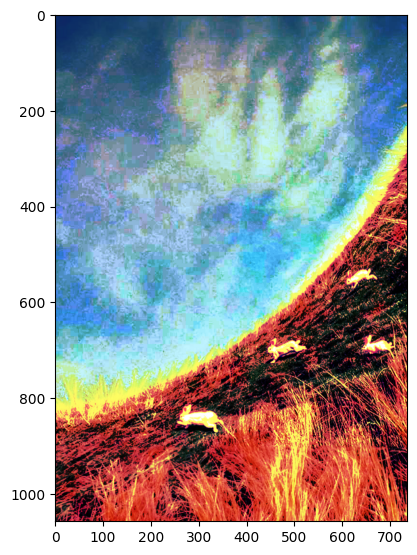

In [3]:
background_bgr = cv.imread('Assets/background.png')

plt.figure(figsize=(10, 10))
plt.subplot(1, 2, 1)
plt.imshow(background_bgr)

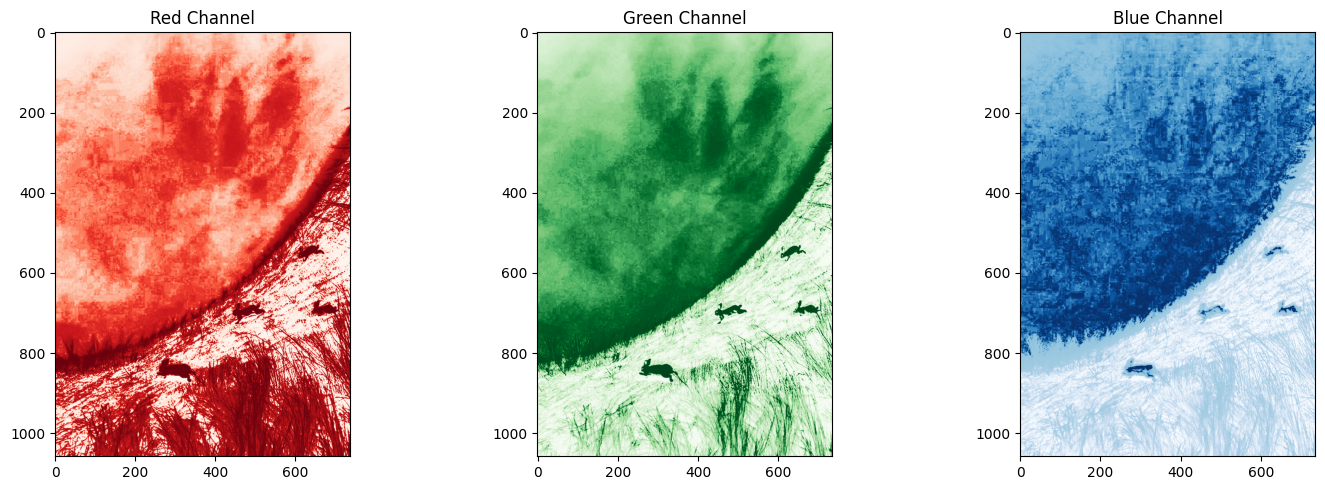

In [4]:
channel_r = background_bgr[:, :, 0] 
channel_g = background_bgr[:, :, 1] 
channel_b = background_bgr[:, :, 2] 

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(channel_r, cmap='Reds') 
plt.title("Red Channel")

plt.subplot(1, 3, 2)
plt.imshow(channel_g, cmap='Greens')
plt.title("Green Channel")

plt.subplot(1, 3, 3)
plt.imshow(channel_b, cmap='Blues')
plt.title("Blue Channel")

plt.tight_layout()
plt.show()

(0.0, 255.0)

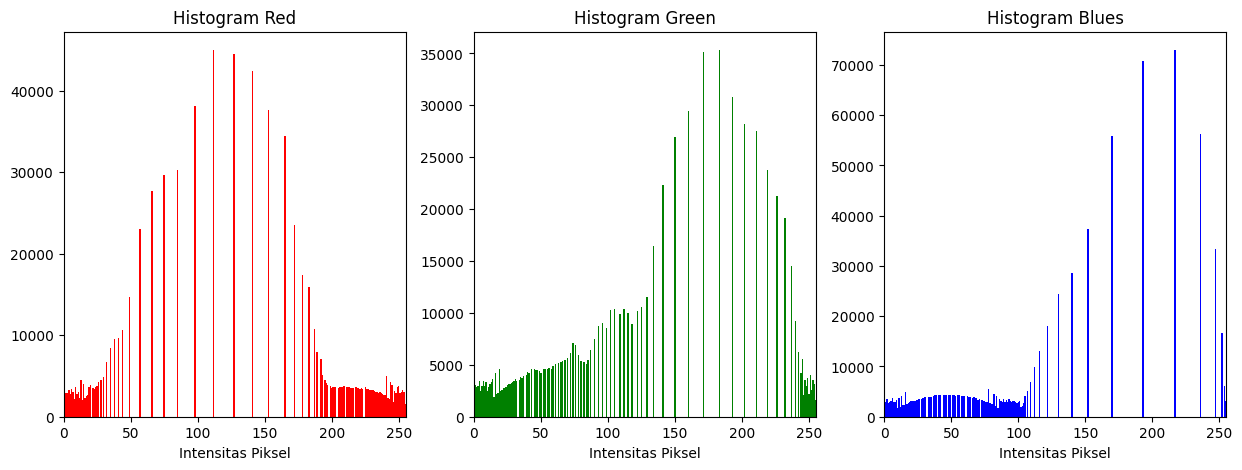

In [5]:
def hitung_hist(citra):
    histogram = np.zeros(256, dtype=int)
    for i in range(citra.shape[0]):
        for j in range(citra.shape[1]):
            histogram[citra[i, j]] += 1
    return histogram

hist_r = hitung_hist(channel_r)
hist_g = hitung_hist(channel_g)
hist_b = hitung_hist(channel_b)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.bar(range(256), hist_r, color='red', width=1.0)
plt.title('Histogram Red')
plt.xlabel('Intensitas Piksel')
plt.xlim([0, 255])

plt.subplot(1, 3, 2)
plt.bar(range(256), hist_g, color='green', width=1.0)
plt.title('Histogram Green')
plt.xlabel('Intensitas Piksel')
plt.xlim([0, 255])

plt.subplot(1, 3, 3)
plt.bar(range(256), hist_b, color='blue', width=1.0)
plt.title('Histogram Blues')
plt.xlabel('Intensitas Piksel')
plt.xlim([0, 255])

(1058, 736) (1058, 736) (1058, 736)


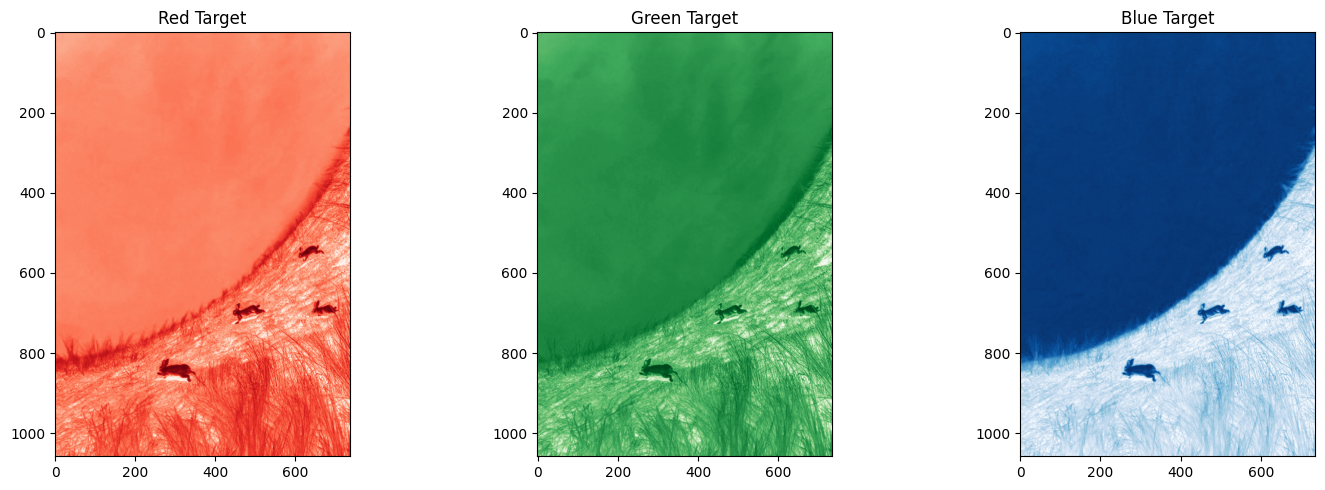

In [6]:
redt_gray = cv.imread('Assets/red_target.png', cv.IMREAD_GRAYSCALE)
greent_gray = cv.imread('Assets/green_target.png', cv.IMREAD_GRAYSCALE)
bluet_gray = cv.imread('Assets/blue_target.png', cv.IMREAD_GRAYSCALE)

plt.figure(figsize=(15, 5))
print(redt_gray.shape, greent_gray.shape, bluet_gray.shape)

plt.subplot(1, 3, 1)
plt.imshow(redt_gray, cmap="Reds") 
plt.title("Red Target")

plt.subplot(1, 3, 2)
plt.imshow(greent_gray, cmap="Greens") 
plt.title("Green Target")

plt.subplot(1, 3, 3)
plt.imshow(bluet_gray, cmap="Blues") 
plt.title("Blue Target")

plt.tight_layout()
plt.show()


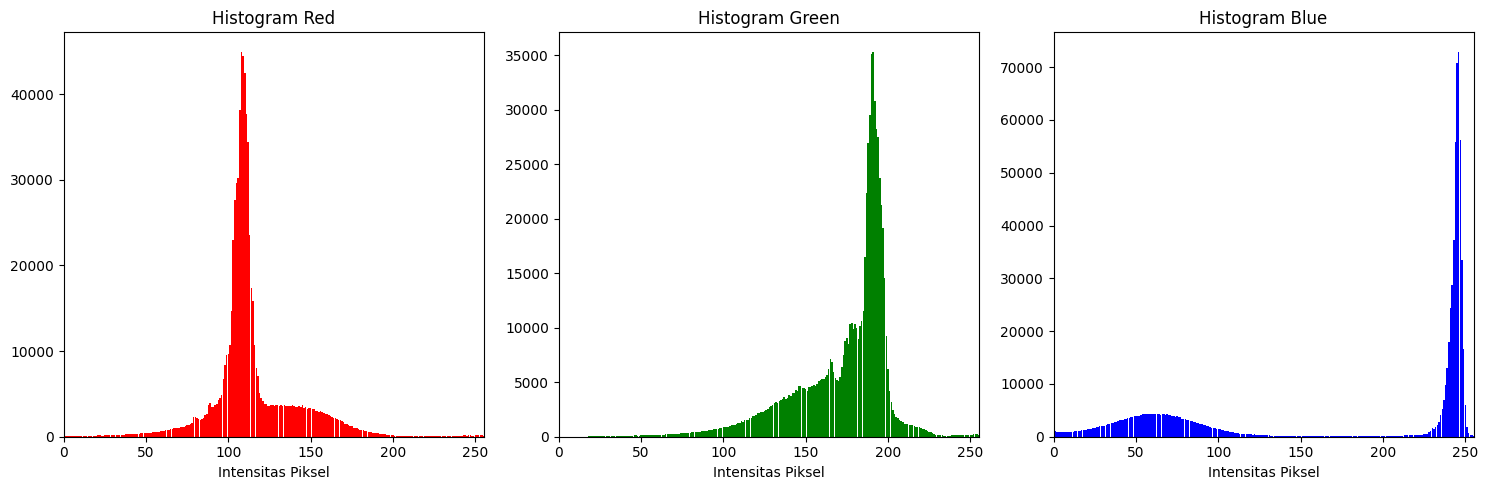

In [7]:

hist_r_t = hitung_hist(redt_gray)
hist_g_t = hitung_hist(greent_gray)
hist_b_t = hitung_hist(bluet_gray)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.bar(range(256), hist_r_t, color='red', width=0.9)
plt.title('Histogram Red')
plt.xlabel('Intensitas Piksel')
plt.xlim([0, 255])

plt.subplot(1, 3, 2)
plt.bar(range(256), hist_g_t, color='green', width=0.9)
plt.title('Histogram Green')
plt.xlabel('Intensitas Piksel')
plt.xlim([0, 255])

plt.subplot(1, 3, 3)
plt.bar(range(256), hist_b_t, color='blue', width=0.9)
plt.title('Histogram Blue') 
plt.xlabel('Intensitas Piksel')
plt.xlim([0, 255])

plt.tight_layout()
plt.show()

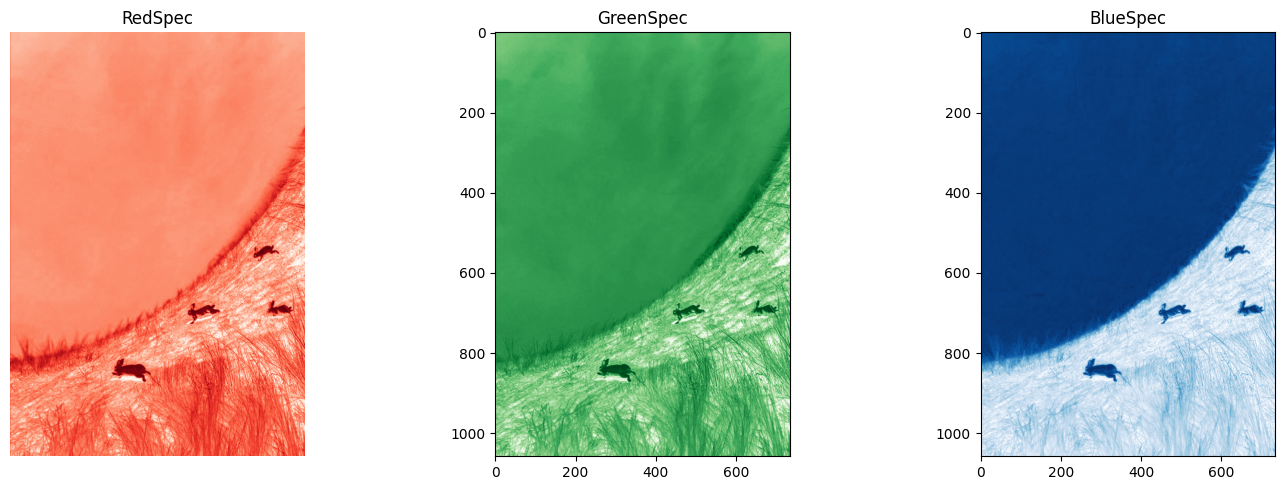

In [8]:
def spesifikasi_histogram(citra_asal, citra_target):
    hist_asal = np.zeros(256, dtype=int)
    hist_target = np.zeros(256, dtype=int)
    
    for i in range(citra_asal.shape[0]):
        for j in range(citra_asal.shape[1]):
            hist_asal[citra_asal[i, j]] += 1
            
    for i in range(citra_target.shape[0]):
        for j in range(citra_target.shape[1]):
            hist_target[citra_target[i, j]] += 1
            
    cdf_asal = np.zeros(256, dtype=float)
    cdf_target = np.zeros(256, dtype=float)
    
    cdf_asal[0] = hist_asal[0]
    cdf_target[0] = hist_target[0]
    
    for i in range(1, 256):
        cdf_asal[i] = cdf_asal[i-1] + hist_asal[i]
        cdf_target[i] = cdf_target[i-1] + hist_target[i]
        
    cdf_asal = cdf_asal / cdf_asal[-1]
    cdf_target = cdf_target / cdf_target[-1]
    
    map_hist = np.zeros(256, dtype=np.uint8)
    for i in range(256):
        selisih = np.abs(cdf_target - cdf_asal[i])
        map_hist[i] = np.argmin(selisih)
        
    height, width = citra_asal.shape
    hasil = np.zeros((height, width), dtype=np.uint8)
    for i in range(height):
        for j in range(width):
            hasil[i, j] = map_hist[citra_asal[i, j]]
            
    return hasil

rt_spec = spesifikasi_histogram(channel_r, redt_gray)
gt_spec = spesifikasi_histogram(channel_g, greent_gray)
bt_spec = spesifikasi_histogram(channel_b, bluet_gray)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(rt_spec, cmap="Reds")
plt.title('RedSpec')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(gt_spec, cmap="Greens")
plt.title('GreenSpec')

plt.subplot(1, 3, 3)
plt.imshow(bt_spec, cmap="Blues")
plt.title('BlueSpec')

plt.tight_layout()
plt.show()

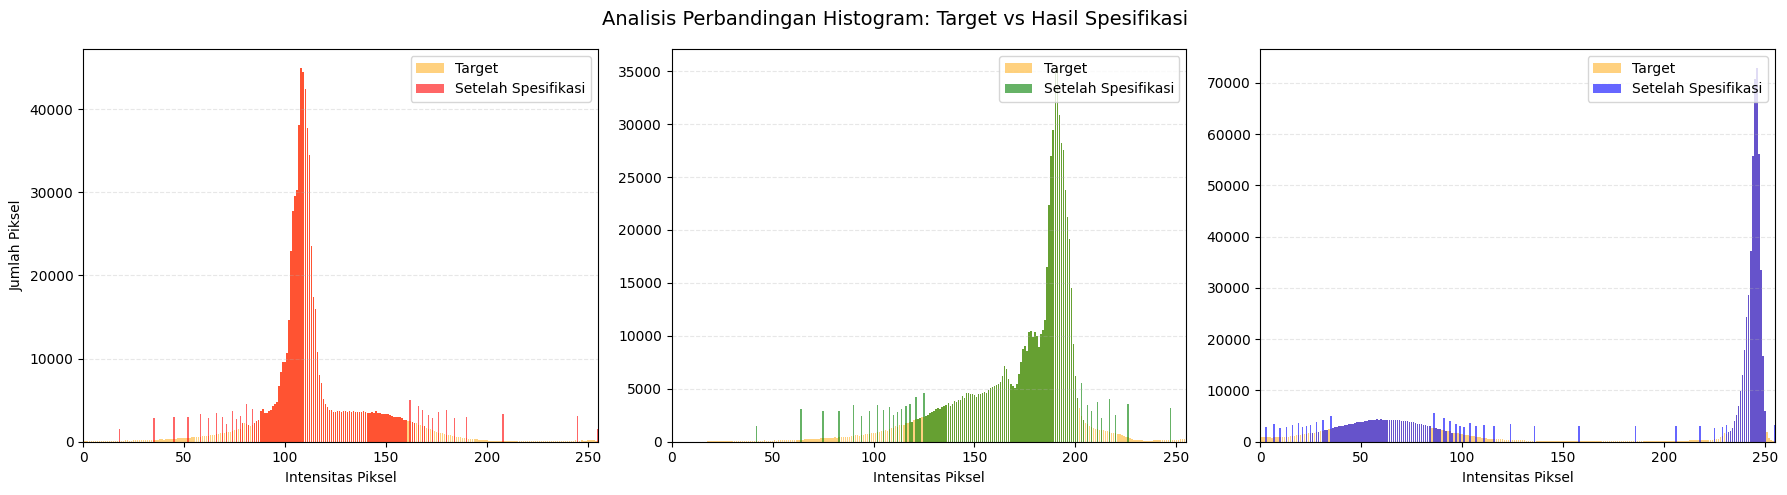

In [9]:
hist_rt_spec = hitung_hist(rt_spec)
hist_gt_spec = hitung_hist(gt_spec)
hist_bt_spec = hitung_hist(bt_spec)

plt.figure(figsize=(18, 5))

plt.suptitle('Analisis Perbandingan Histogram: Target vs Hasil Spesifikasi', fontsize=14)

plt.subplot(1, 3, 1)

plt.bar(range(256), hist_r_t, color='orange', alpha=0.5, label='Target', width=0.7)
plt.bar(range(256), hist_rt_spec, color='red', alpha=0.6, label='Setelah Spesifikasi', width=0.7)
plt.xlabel('Intensitas Piksel')
plt.ylabel('Jumlah Piksel')
plt.legend(loc='upper right')
plt.xlim([0, 255])
plt.grid(axis='y', linestyle='--', alpha=0.3) 

plt.subplot(1, 3, 2)
plt.bar(range(256), hist_g_t, color='orange', alpha=0.5, label='Target', width=0.7)
plt.bar(range(256), hist_gt_spec, color='green', alpha=0.6, label='Setelah Spesifikasi', width=0.7)
plt.xlabel('Intensitas Piksel')
plt.legend(loc='upper right')
plt.xlim([0, 255])
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.subplot(1, 3, 3)
plt.bar(range(256), hist_b_t, color='orange', alpha=0.5, label='Target', width=0.8)
plt.bar(range(256), hist_bt_spec, color='blue', alpha=0.6, label='Setelah Spesifikasi', width=0.8)
plt.xlabel('Intensitas Piksel')
plt.legend(loc='upper right')
plt.xlim([0, 255])
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

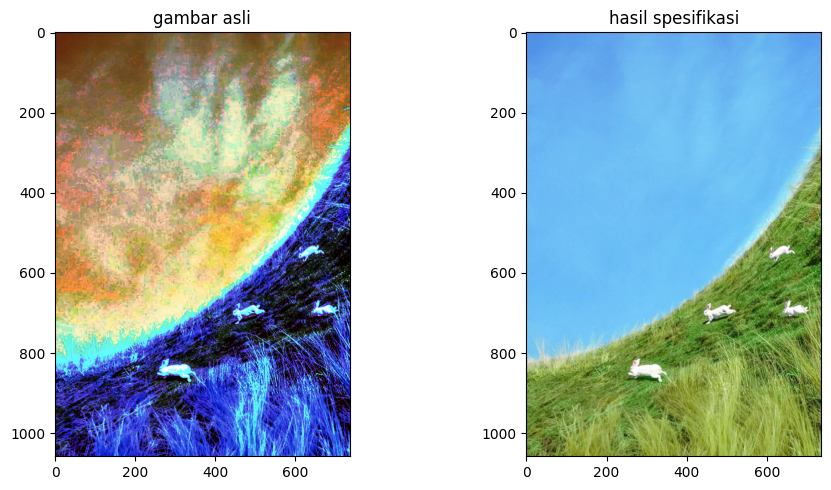

In [ ]:
h, w = rt_spec.shape

hasil_gabungan = np.zeros((h, w, 3), dtype=np.uint8)

hasil_gabungan[:, :, 0] = rt_spec
hasil_gabungan[:, :, 1] = gt_spec
hasil_gabungan[:, :, 2] = bt_spec

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)

plt.imshow(background_bgr[:, :, ::-1]) 
plt.title('gambar asli')

plt.subplot(1, 2, 2)
plt.imshow(hasil_gabungan)
plt.title('hasil spesifikasi')

plt.tight_layout()
plt.show()

(529, 368, 3)


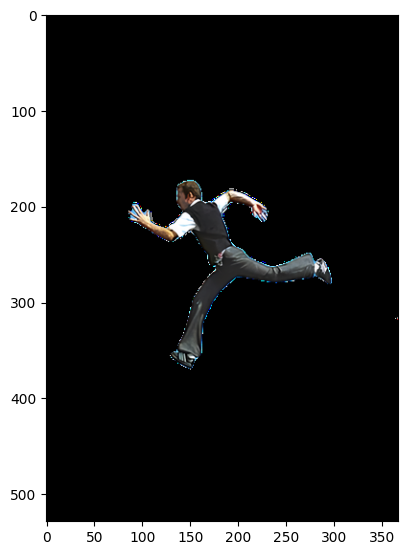

In [11]:
foreground_bgr = cv.imread('Assets/foreground.png')
foreground_rgb = cv.cvtColor(foreground_bgr, cv.COLOR_BGR2RGB)
print(foreground_rgb.shape)
plt.figure(figsize=(10, 10))
plt.subplot(1, 2, 1)
plt.imshow(foreground_rgb)

(1058, 736, 3)


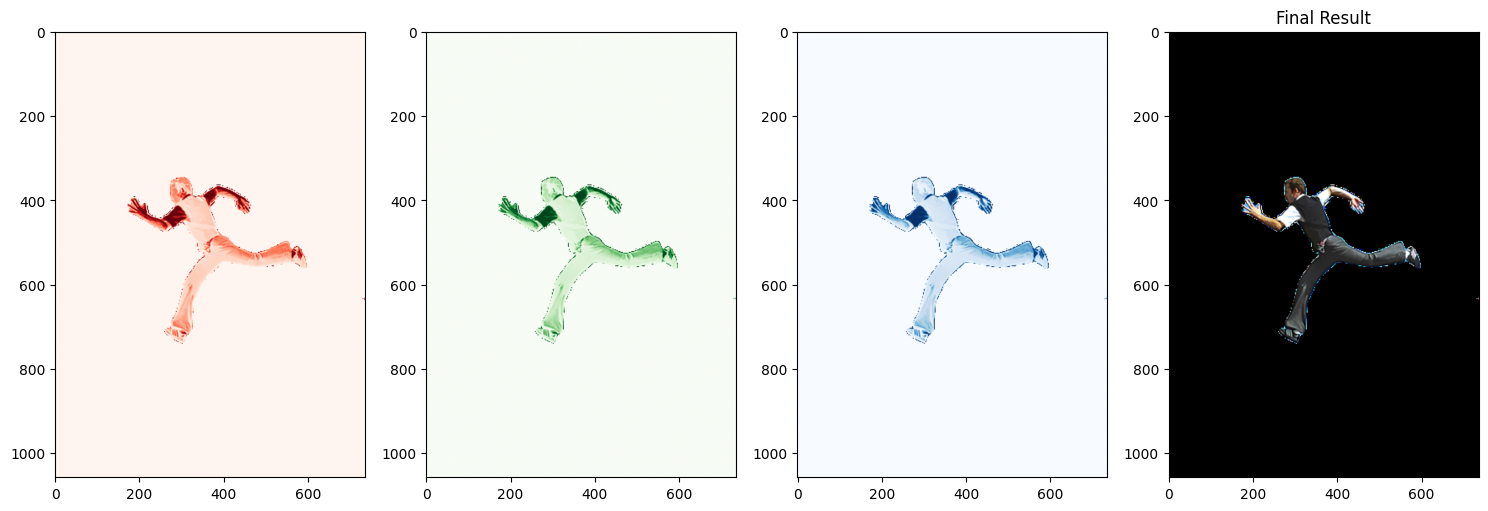

In [ ]:
target_h, target_w = hasil_gabungan.shape[:2]

old_h, old_w = foreground_rgb.shape[:2]

r_chan = foreground_rgb[:, :, 0]
g_chan = foreground_rgb[:, :, 1]
b_chan = foreground_rgb[:, :, 2]

r_resized = np.zeros((target_h, target_w), dtype=np.uint8)
g_resized = np.zeros((target_h, target_w), dtype=np.uint8)
b_resized = np.zeros((target_h, target_w), dtype=np.uint8)

foreground_final = np.zeros((target_h, target_w, 3), dtype=np.uint8)

rasio_h = old_h / target_h
rasio_w = old_w / target_w

for i in range(target_h):
    for j in range(target_w):
        src_y = int(i * rasio_h)
        src_x = int(j * rasio_w)
        
        r_resized[i, j] = r_chan[src_y, src_x]
        g_resized[i, j] = g_chan[src_y, src_x]
        b_resized[i, j] = b_chan[src_y, src_x]
        
        foreground_final[i, j, 0] = r_chan[src_y, src_x]
        foreground_final[i, j, 1] = g_chan[src_y, src_x]
        foreground_final[i, j, 2] = b_chan[src_y, src_x]

plt.figure(figsize=(15, 5))
print(foreground_final.shape)
plt.subplot(1, 4, 1)
plt.imshow(r_resized, cmap="Reds")

plt.subplot(1, 4, 2)
plt.imshow(g_resized, cmap="Greens")

plt.subplot(1, 4, 3)
plt.imshow(b_resized, cmap="Blues")

plt.subplot(1, 4, 4)
plt.imshow(foreground_final)
plt.title('Final Result')

plt.tight_layout()
plt.show()

(1058, 736, 3)


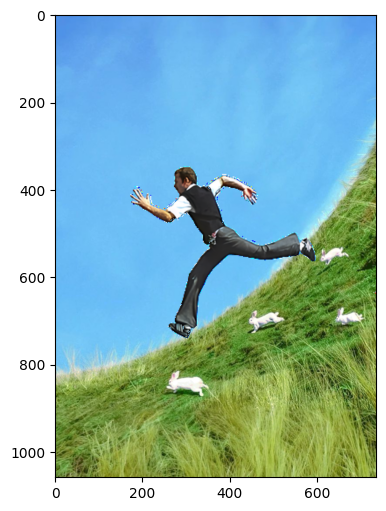

In [13]:
target_h, target_w = hasil_gabungan.shape[:2]
citra_komposit = np.zeros((target_h, target_w, 3), dtype=np.uint8)

for i in range(target_h):
    for j in range(target_w):
        if foreground_final[i, j, 0] > 0 or foreground_final[i, j, 1] > 0 or foreground_final[i, j, 2] > 0:
            citra_komposit[i, j, 0] = foreground_final[i, j, 0]
            citra_komposit[i, j, 1] = foreground_final[i, j, 1]
            citra_komposit[i, j, 2] = foreground_final[i, j, 2]
        else:
            citra_komposit[i, j, 0] = hasil_gabungan[i, j, 0]
            citra_komposit[i, j, 1] = hasil_gabungan[i, j, 1]
            citra_komposit[i, j, 2] = hasil_gabungan[i, j, 2]

print(citra_komposit.shape)

plt.figure(figsize=(6, 6))
plt.imshow(citra_komposit)
plt.show()

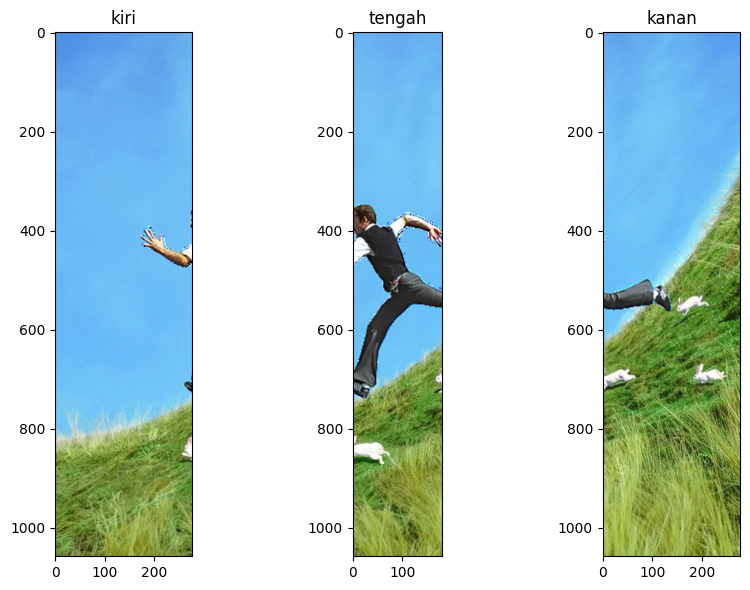

In [14]:
cut1 = 277
cut2 = 458

kiri = citra_komposit[:, :cut1]
tengah = citra_komposit[:, cut1:cut2]
kanan = citra_komposit[:, cut2:]

plt.figure(figsize=(9, 6))

plt.subplot(1, 3, 1)
plt.imshow(kiri)
plt.title('kiri')

plt.subplot(1, 3, 2)
plt.imshow(tengah)
plt.title('tengah')

plt.subplot(1, 3, 3)
plt.imshow(kanan)
plt.title('kanan')

plt.tight_layout()
plt.show()

(0.0, 255.0)

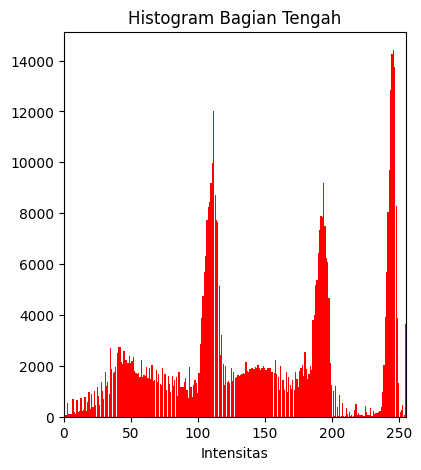

In [15]:
hist_tengah = hitung_hist(tengah)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.bar(range(256), hist_tengah, color='red', width=0.9)
plt.title('Histogram Bagian Tengah')
plt.xlabel('Intensitas')
plt.xlim([0, 255])

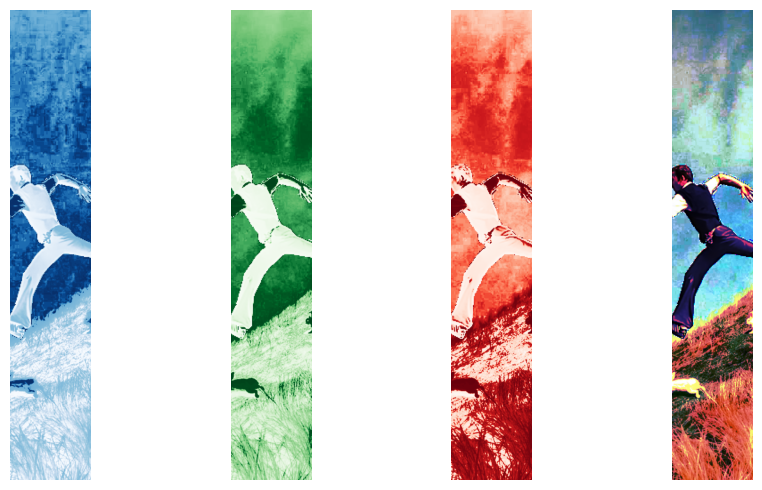

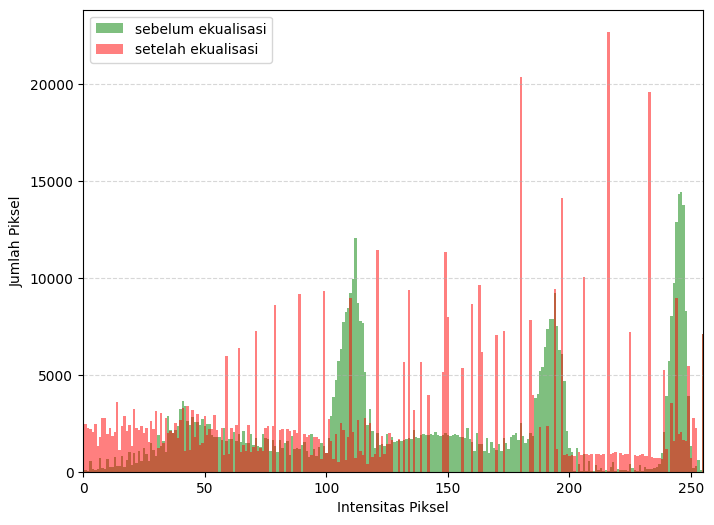

In [16]:
def ekualisasi(citra):
    height, width = citra.shape
    hist = np.zeros(256, dtype=int)
    
    for i in range(height):
        for j in range(width):
            hist[citra[i, j]] += 1

    cdf = np.zeros(256, dtype=int)
    cdf[0] = hist[0]
    for i in range(1, 256):
        cdf[i] = cdf[i-1] + hist[i]
        
    cdf_normal = np.round(cdf * 255 / (height * width)).astype(np.uint8)
    
    hasil = np.zeros_like(citra, dtype=np.uint8)
    for i in range(height):
        for j in range(width):
            hasil[i, j] = cdf_normal[citra[i, j]]
            
    return hasil

r_tengah = tengah[:, :, 0]
g_tengah = tengah[:, :, 1]
b_tengah = tengah[:, :, 2]

r_eq = ekualisasi(r_tengah)
g_eq = ekualisasi(g_tengah)
b_eq = ekualisasi(b_tengah)

tengah_eq = np.zeros((tengah.shape[0], tengah.shape[1], 3), dtype=np.uint8)
for i in range(tengah.shape[0]):
    for j in range(tengah.shape[1]):
        tengah_eq[i, j, 0] = r_eq[i, j]
        tengah_eq[i, j, 1] = g_eq[i, j]
        tengah_eq[i, j, 2] = b_eq[i, j]

plt.figure(figsize=(10, 5))

plt.subplot(1, 4, 1)
plt.imshow(b_eq, cmap='Blues')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(g_eq, cmap='Greens')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(r_eq, cmap='Reds')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(tengah_eq)
plt.axis('off')

plt.tight_layout()
plt.show()

hist_sebelum = np.zeros(256, dtype=int)
hist_setelah = np.zeros(256, dtype=int)

for i in range(tengah.shape[0]):
    for j in range(tengah.shape[1]):
        for k in range(3):
            hist_sebelum[tengah[i, j, k]] += 1
            hist_setelah[tengah_eq[i, j, k]] += 1
            

plt.figure(figsize=(8, 6))
plt.bar(range(256), hist_sebelum, color='green', alpha=0.5, label='sebelum ekualisasi', width=1.0)
plt.bar(range(256), hist_setelah, color='red', alpha=0.5, label='setelah ekualisasi', width=1.0)
plt.xlabel('Intensitas Piksel')
plt.ylabel('Jumlah Piksel')
plt.legend(loc='upper left')
plt.xlim([0, 255])
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

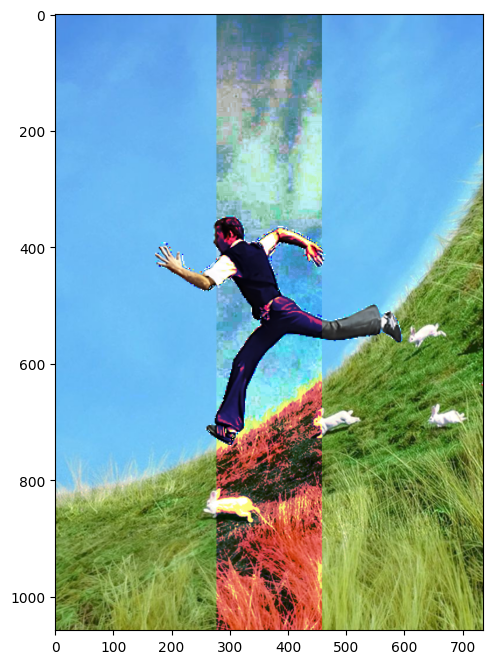

In [17]:
citra_final = np.zeros((h, w, 3), dtype=np.uint8)

for i in range(h):
    for j in range(cut1):
        citra_final[i, j, 0] = kiri[i, j, 0]
        citra_final[i, j, 1] = kiri[i, j, 1]
        citra_final[i, j, 2] = kiri[i, j, 2]

lebar_tengah = cut2 - cut1
for i in range(h):
    for j in range(lebar_tengah):
        citra_final[i, j + cut1, 0] = tengah_eq[i, j, 0]
        citra_final[i, j + cut1, 1] = tengah_eq[i, j, 1]
        citra_final[i, j + cut1, 2] = tengah_eq[i, j, 2]

lebar_kanan = w - cut2
for i in range(h):
    for j in range(lebar_kanan):
        citra_final[i, j + cut2, 0] = kanan[i, j, 0]
        citra_final[i, j + cut2, 1] = kanan[i, j, 1]
        citra_final[i, j + cut2, 2] = kanan[i, j, 2]

plt.figure(figsize=(6, 8))
plt.imshow(citra_final)
plt.show()

# Kesimpulan
Responny Seru bangettt!!!! tapi nda tau kenapa histogramnya beda sama kj padahal warna udh sesuai 100% huff, anyway kita jadi tahu cara buat mecahin warna rgb jdi warna tunggal terus distribusi ke masing masing citra sesuai yang kita inginkan dan dengan Spesifikasi Histogram, kita bisa mindahin "vibes" atau suasana warna dari satu foto ke foto lain secara matematis. Yang tadinya fotonya kelihatan suram atau salah warna, bisa berubah total jadi estetik cuma karena kita nyamain grafik distribusinya, trus disini ada menggabung beberapa potongan gambar yang udh di ekualisasi sebelumnya dan hasilnya keren bgt, thanks bg dodi.